# Experiments

## RandomAlgorithm experiment

### Read configuration


### Plot RandomAlgorithm Experiment

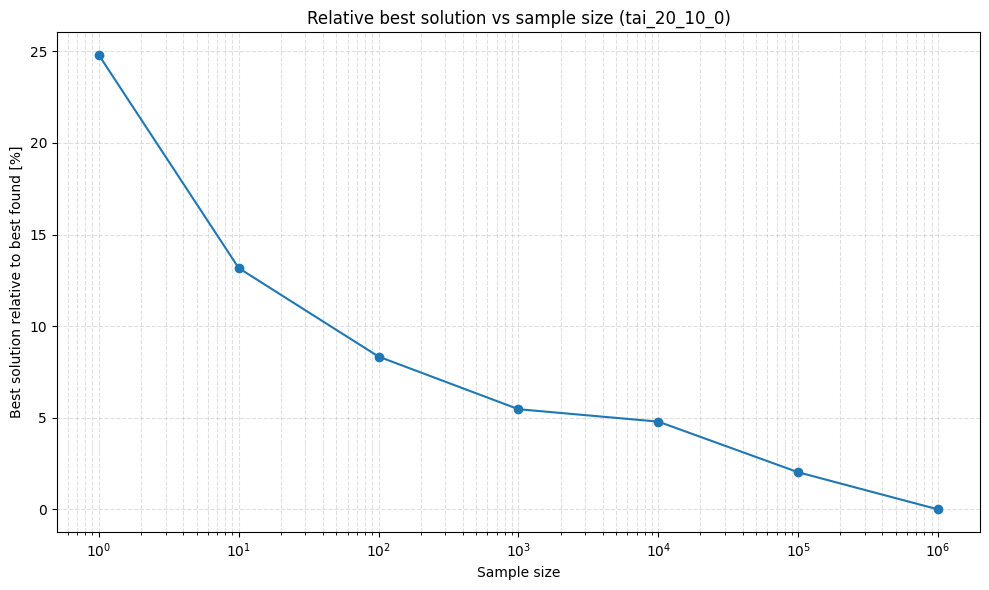

In [7]:

import matplotlib.pyplot as plt

target_instance = "tai_20_10_0"
instance_df = csv_df[csv_df["Instance"] == target_instance].copy()
if instance_df.empty:
    raise ValueError(f"Instance '{target_instance}' not found in {csv_path.name}.")

best_cost = instance_df["BestCost"].min()
instance_df["RelativeBestCostPct"] = ((instance_df["BestCost"] / best_cost) - 1.0) * 100.0

ax = instance_df.plot(
    x="Evaluations",
    y="RelativeBestCostPct",
    marker="o",
    figsize=(10, 6),
    logx=True,
    legend=False,
    color="#1f77b4",
)

ax.set_xlabel("Sample size")
ax.set_ylabel("Best solution relative to best found [%]")
ax.set_title(f"Relative best solution vs sample size ({target_instance})")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# All algorithm comparison test

## Read algorithm comparison experiment configuration

In [31]:
from pathlib import Path
import subprocess

from file_io import list_supported_experiment_files, load_experiment_file

results_dir = Path("..") / "ExperimentRunner" / "experiment_results"
files = list_supported_experiment_files(results_dir)

csv_path = next((p for p in files if p.suffix.lower() == ".csv"), None)
if csv_path is None:
    raise FileNotFoundError("No .csv experiment file found in 'files'.")

csv_df = load_experiment_file(csv_path).copy()
csv_df = csv_df.sort_values(["Instance", "Evaluations"])


repo_root = Path.cwd().resolve().parent
config_path = repo_root / "Analysis" / "experimentrunner.default_all_instances.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
 )

print(result.stdout)
if result.stderr.strip():
    print("STDERR:\n" + result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {result.returncode}")
print("ExperimentRunner finished successfully.")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Analysis\experimentrunner.default_all_instances.json
Experiment Runner
Running Random_10000_s12345 on tai_20_5_0 (seed 12345)...
tai_20_5_0,Random_10000_s12345,RandomSearchParameters,12345,15217,10000,15.0384,-1,2026-03-20T08:33:43.2553503+00:00
Running Evolutionary_p100_g100_s12345 on tai_20_5_0 (seed 12345)...
tai_20_5_0,Evolutionary_p100_g100_s12345,EvolutionaryParameters,12345,14556,10100,11.5014,9795,2026-03-20T08:33:43.2679658+00:00
Running SimulatedAnnealing_nSwap_i10000_s12345 on tai_20_5_0...
tai_20_5_0,SimulatedAnnealing_nSwap_i10000_s12345,SimulatedAnnealingParameters,,14304,10001,10.312,348,2026-03-20T08:33:43.2785493+00:00
Running Greedy on tai_20_5_0...
tai_20_5_0,Greedy,GreedyParameters,,14286,1,2.1831,-1,2026-03-20T08:33:43.2809924+00:00
Running Random_10000_s12345 on tai_20_10_0 (seed 12345)...
tai_20_10_0,Random_10000_s12345,RandomSearchParameters,12345,

## Plot all algorithm comparison

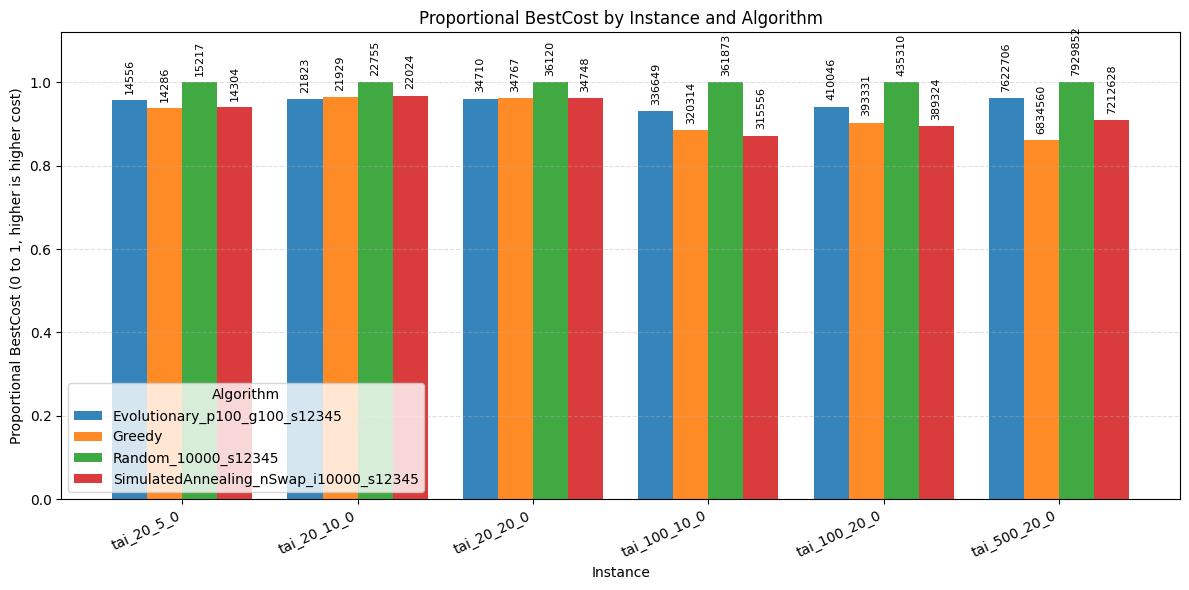

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from file_io import read_csv

csv_path = Path("Experiments") / "experiment_study.csv"
df = read_csv(csv_path)
instance_order = df["Instance"].drop_duplicates().tolist()

pivot = df.pivot_table(
    index="Instance",
    columns="Algorithm",
    values="BestCost",
    aggfunc="min",
)
pivot = pivot.reindex(instance_order)

# Per-instance proportional score in [0, 1]
row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

instances = score_pivot.index.to_list()
algorithms = score_pivot.columns.to_list()
x = np.arange(len(instances))
width = 0.8 / max(len(algorithms), 1)

fig, ax = plt.subplots(figsize=(12, 6))
for idx, alg in enumerate(algorithms):
    offset = (idx - (len(algorithms) - 1) / 2) * width
    heights = score_pivot[alg].values
    bars = ax.bar(
        x + offset,
        heights,
        width=width,
        label=alg,
        alpha=0.9,
    )

    # Show BestCost values on bars.
    for bar, cost in zip(bars, pivot[alg].values):
        if pd.notna(cost):
            y = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y + 0.015,
                f"{int(cost)}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("Proportional BestCost by Instance and Algorithm")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Algorithm")
plt.tight_layout()
plt.show()


# 2 Parameter Evolutionary test

## Run 2D evolutionary experiment

In [17]:
repo_root = Path.cwd().resolve().parent
config_path = repo_root / "Analysis" / "experimentrunner.tai_20_5_0.evolutionary_2d_256.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
run_result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
 )

print(run_result.stdout)
if run_result.stderr.strip():
    print("STDERR:\n" + run_result.stderr)
if run_result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {run_result.returncode}")


Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Analysis\experimentrunner.tai_20_5_0.evolutionary_2d_256.json
Experiment Runner
Running Evolutionary_p10_g10_s0 on tai_20_5_0 (seed 0)...
tai_20_5_0,Evolutionary_p10_g10_s0,EvolutionaryParameters,0,16262,110,2.5368,87,2026-03-20T00:11:34.9654663+00:00
Running Evolutionary_p10_g20_s0 on tai_20_5_0 (seed 0)...
tai_20_5_0,Evolutionary_p10_g20_s0,EvolutionaryParameters,0,15587,210,0.2356,149,2026-03-20T00:11:34.9666168+00:00
Running Evolutionary_p10_g30_s0 on tai_20_5_0 (seed 0)...
tai_20_5_0,Evolutionary_p10_g30_s0,EvolutionaryParameters,0,15638,310,0.3348,254,2026-03-20T00:11:34.9671590+00:00
Running Evolutionary_p10_g40_s0 on tai_20_5_0 (seed 0)...
tai_20_5_0,Evolutionary_p10_g40_s0,EvolutionaryParameters,0,15237,410,0.4185,328,2026-03-20T00:11:34.9677170+00:00
Running Evolutionary_p10_g50_s0 on tai_20_5_0 (seed 0)...
tai_20_5_0,Evolutionary_p10_g50_s0,EvolutionaryParamete

## Plot 2D Pop/Gen experiment

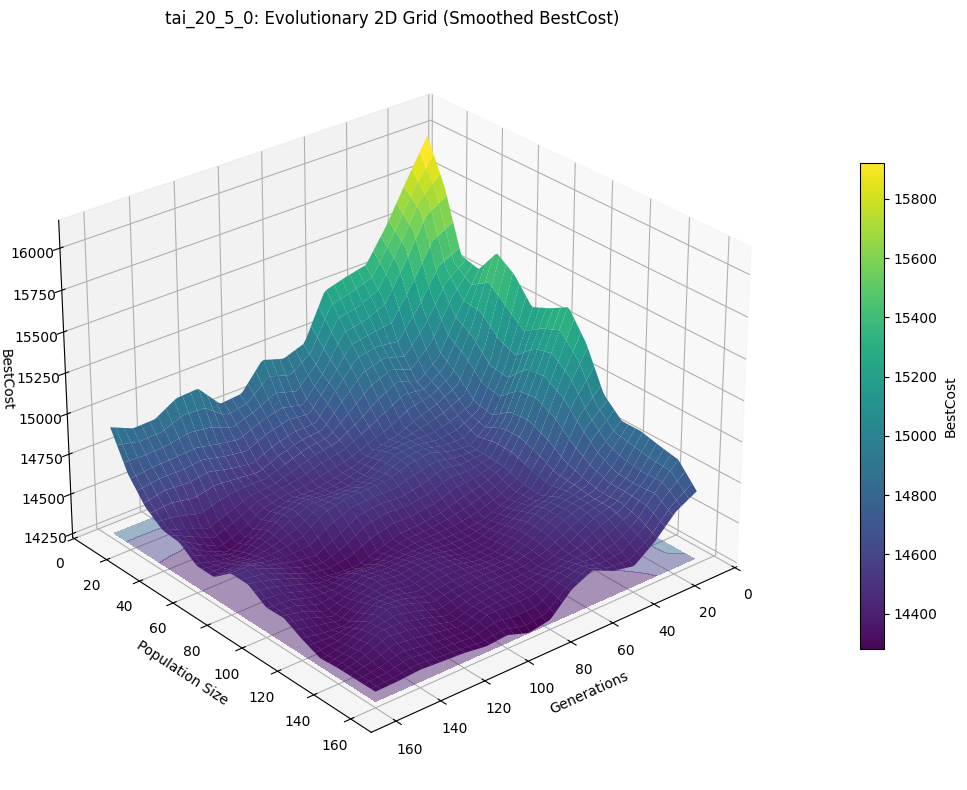

In [22]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv = repo_root / "Analysis" / "Experiments" / "tai_20_5_0_evolutionary_2d_256" / "experiment_study.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"Expected results file not found: {results_csv}")

df = pd.read_csv(results_csv)
df = df[df["Instance"] == "tai_20_5_0"].copy()

pattern = re.compile(r"Evolutionary_p(?P<p>\d+)_g(?P<g>\d+)_s(?P<s>\d+)")
parsed = df["Algorithm"].str.extract(pattern)
df["PopulationSize"] = pd.to_numeric(parsed["p"], errors="coerce")
df["Generations"] = pd.to_numeric(parsed["g"], errors="coerce")
df = df.dropna(subset=["PopulationSize", "Generations", "BestCost"]).copy()

df["PopulationSize"] = df["PopulationSize"].astype(int)
df["Generations"] = df["Generations"].astype(int)

surface_df = df.pivot_table(
    index="Generations",
    columns="PopulationSize",
    values="BestCost",
    aggfunc="min",
).sort_index().sort_index(axis=1)

# Optional (install once if needed): pip install scipy
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

# Original regular grid
g_vals = surface_df.index.to_numpy(dtype=float)          # Generations
p_vals = surface_df.columns.to_numpy(dtype=float)        # PopulationSize
Z = surface_df.to_numpy(dtype=float)

# 1) Mild smoothing on original grid
Z_smooth = gaussian_filter(Z, sigma=0.8)

# 2) Upsample to a denser grid for a smoother surface
p_dense = np.linspace(p_vals.min(), p_vals.max(), 120)
g_dense = np.linspace(g_vals.min(), g_vals.max(), 120)
P_dense, G_dense = np.meshgrid(p_dense, g_dense)

interp = RegularGridInterpolator((g_vals, p_vals), Z_smooth, method="linear")
pts = np.column_stack([G_dense.ravel(), P_dense.ravel()])
Z_dense = interp(pts).reshape(G_dense.shape)

# 3D plot (flipped axes: X=Generations, Y=Population Size)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    G_dense,
    P_dense,
    Z_dense,
    cmap="viridis",
    edgecolor="none",      # remove mesh edges for smooth look
    antialiased=True,
    alpha=0.98,
)

ax.contourf(G_dense, P_dense, Z_dense, zdir="z", offset=np.nanmin(Z_dense), cmap="viridis", alpha=0.45)
ax.set_xlabel("Generations")
ax.set_ylabel("Population Size")
ax.set_zlabel("BestCost")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title("tai_20_5_0: Evolutionary 2D Grid (Smoothed BestCost)")
ax.view_init(elev=28, azim=-130)

cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
cbar.set_label("BestCost")
plt.tight_layout()
plt.show()

# SimulatedAnnealing neighbor operators

## Run experiment: all instances × all neighbor operators

In [26]:
from pathlib import Path
import subprocess

repo_root = Path.cwd().resolve().parent
config_path = repo_root / "Analysis" / "experimentrunner.tai_20_5_0.simulatedannealing_neighbors.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
sa_run_result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
)

print(sa_run_result.stdout)
if sa_run_result.stderr.strip():
    print("STDERR:\n" + sa_run_result.stderr)
if sa_run_result.returncode != 0:
    raise RuntimeError(
        f"ExperimentRunner failed with exit code {sa_run_result.returncode}"
    )

print("SimulatedAnnealing neighbor experiment finished successfully.")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Analysis\experimentrunner.tai_20_5_0.simulatedannealing_neighbors.json
Experiment Runner
Running SimulatedAnnealing_nSwap_i20000_s22 on tai_20_5_0...
tai_20_5_0,SimulatedAnnealing_nSwap_i20000_s22,SimulatedAnnealingParameters,,14368,20000,21.4227,779,2026-03-20T00:19:58.0634189+00:00
Running SimulatedAnnealing_nSwap_i20000_s151555 on tai_20_5_0...
tai_20_5_0,SimulatedAnnealing_nSwap_i20000_s151555,SimulatedAnnealingParameters,,14366,20000,18.7154,1587,2026-03-20T00:19:58.0830608+00:00
Running SimulatedAnnealing_nSwap_i20000_s5252525 on tai_20_5_0...
tai_20_5_0,SimulatedAnnealing_nSwap_i20000_s5252525,SimulatedAnnealingParameters,,14339,20000,19.1852,1273,2026-03-20T00:19:58.1025029+00:00
Running SimulatedAnnealing_nSwap_i20000_s6687883 on tai_20_5_0...
tai_20_5_0,SimulatedAnnealing_nSwap_i20000_s6687883,SimulatedAnnealingParameters,,14181,20000,18.6473,1411,2026-03-20T00:

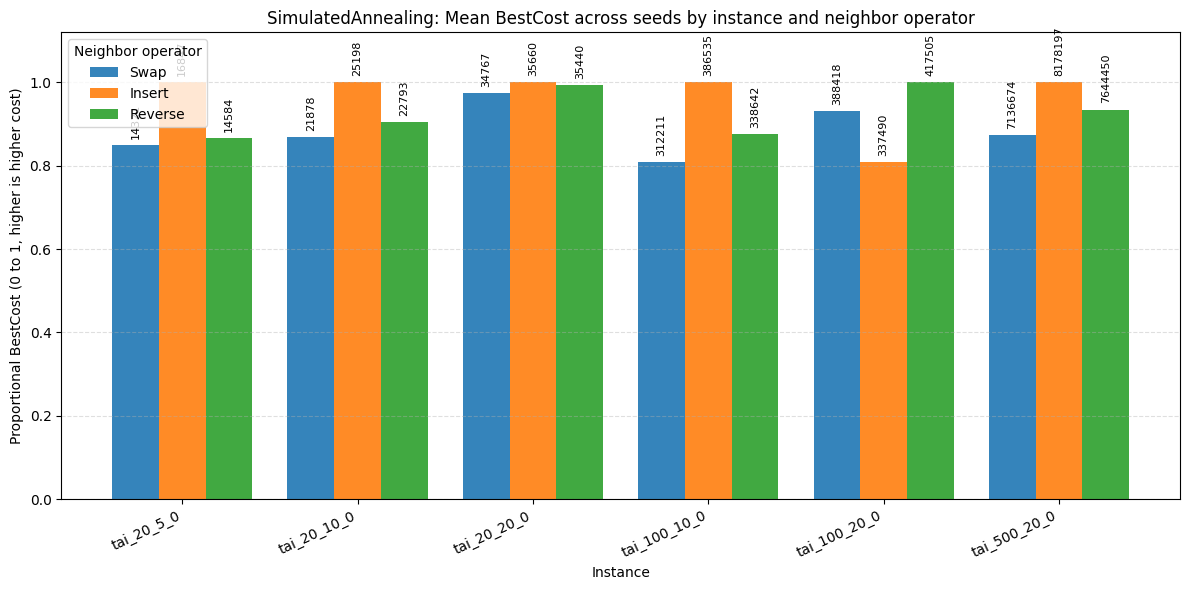

Neighbor,Swap,Insert,Reverse
Instance,,,
tai_20_5_0,0.850100,1.000000,0.865675
tai_20_10_0,0.868248,1.000000,0.904527
tai_20_20_0,0.974964,1.000000,0.993853
tai_100_10_0,0.807719,1.000000,0.876096
tai_100_20_0,0.930331,0.808348,1.000000
tai_500_20_0,0.872646,1.000000,0.934735


In [28]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv = Path("Experiments") / "simulatedannealing_neighbors" / "experiment_study.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"Expected results file not found: {results_csv.resolve()}")

# Read full results
df = pd.read_csv(results_csv)

# Parse NeighborhoodOperator and Seed from algorithm name: SimulatedAnnealing_n{Neighbor}_i{Iters}_s{Seed}
pattern = re.compile(r"SimulatedAnnealing_n(?P<Neighbor>[^_]+)_i\d+_s(?P<Seed>\d+)")
parsed = df["Algorithm"].str.extract(pattern)
df["Neighbor"] = parsed["Neighbor"]
df["Seed"] = pd.to_numeric(parsed["Seed"], errors="coerce")
df = df.dropna(subset=["Neighbor", "BestCost", "Seed"]).copy()

instance_order = df["Instance"].drop_duplicates().tolist()
operator_order = ["Swap", "Insert", "Reverse"]

# For each Instance x Neighbor x Seed take the best (min) BestCost, then average across seeds
mean_by_seed = df.groupby(["Instance", "Neighbor"], as_index=False)["BestCost"].mean()
pivot = mean_by_seed.pivot(index="Instance", columns="Neighbor", values="BestCost").reindex(index=instance_order, columns=operator_order)

# Per-instance proportional score in [0, 1] computed from averaged BestCost across seeds
row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

x = np.arange(len(instance_order))
width = 0.8 / len(operator_order)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(12, 6))
for idx, op in enumerate(operator_order):
    offset = (idx - (len(operator_order) - 1) / 2) * width
    heights = score_pivot[op].values
    bars = ax.bar(x + offset, heights, width=width, label=op,
                  alpha=0.9, color=colors[idx])

    for bar, val in zip(bars, pivot[op].values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{int(val)}",
                ha="center", va="bottom", fontsize=8, rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instance_order, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("SimulatedAnnealing: Mean BestCost across seeds by instance and neighbor operator")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Neighbor operator")
plt.tight_layout()
plt.show()

score_pivot